# Introduction to Data Science 2026

# Week 2

## Exercise 1 | Titanic: data preprocessing and imputation
<span style="font-weight: bold"> *Note: You can find tutorials for NumPy and Pandas under 'Useful tutorials' in the course material.*</span>

Download the [Titanic dataset](https://www.kaggle.com/c/titanic) [train.csv] from Kaggle or <span style="font-weight: 500">directly from the course material</span>, and complete the following exercises. If you choose to download the dataset from Kaggle, you will need to create a Kaggle account unless you already have one, but it is quite straightforward.

The dataset consists of personal information of all the passengers on board the RMS Titanic, along with information about whether they survived the iceberg collision or not.

1. Your first task is to read the data file and print the shape of the data.

    <span style="font-weight: 500"> *Hint 1: You can read them into a Pandas dataframe if you wish.*</span>
    
    <span style="font-weight: 500"> *Hint 2: The shape of the data should be (891, 12).*</span>

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('train.csv')
print(df.shape)

(891, 12)


2. Let's look at the data and get started with some preprocessing. Some of the columns, e.g <span style="font-weight: 500"> *Name*</span>, simply identify a person and are not useful for prediction tasks. Try to identify these columns, and remove them.

    <span style="font-weight: 500"> *Hint: The shape of the data should now be (891, 9).*</span>

In [2]:
# PassengerId, Name and Ticket only identify the passenger, so they are not useful for prediction
df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])
print(df.shape)

(891, 9)


3. The column <span style="font-weight: 500">*Cabin*</span> contains a letter and a number. A smart catch at this point would be to notice that the letter stands for the deck level on the ship. Keeping just the deck information would be more informative when developing, e.g. a classifier that predicts whether a passenger survived. The next step in our preprocessing will be to add a new column to the dataset, which consists simply of the deck letter. You can then remove the original <span style="font-weight: 500">*Cabin*</span>-column.

<span style="font-weight: 500">*Hint: The deck letters should be ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'T'].*</span>

In [3]:
df['Deck'] = df['Cabin'].str[0]
df = df.drop(columns=['Cabin'])
print(np.sort(df['Deck'].dropna().unique()))

['A' 'B' 'C' 'D' 'E' 'F' 'G' 'T']


4. You’ll notice that some of the columns, such as the previously added deck number, are [categorical](https://en.wikipedia.org/wiki/Categorical_variable). To preprocess the categorical variables so that they're ready for further computation, we need to avoid the current string format of the values. This means the next step for each categorical variable is to transform the string values to numeric ones, that correspond to a unique integer ID representative of each distinct category. This process is called label encoding and you can read more about it [here](https://pandas.pydata.org/docs/user_guide/categorical.html).

    <span style="font-weight: 500">*Hint: Pandas can do this for you.*</span>

In [4]:
for col in ['Sex', 'Embarked', 'Deck']:
    df[col] = df[col].astype('category')
    print(col, dict(enumerate(df[col].cat.categories)))
    df[col] = df[col].cat.codes
    # missing values get the code -1, so set them back to NaN for the imputation step
    df[col] = df[col].replace(-1, np.nan)

df.head()

Sex {0: 'female', 1: 'male'}
Embarked {0: 'C', 1: 'Q', 2: 'S'}
Deck {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'T'}


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck
0,0,3,1,22.0,1,0,7.2500,2.0,NaN
1,1,1,0,38.0,1,0,71.2833,0.0,2.0
2,1,3,0,26.0,0,0,7.9250,2.0,NaN
3,1,1,0,35.0,1,0,53.1000,2.0,2.0
4,0,3,1,35.0,0,0,8.0500,2.0,NaN


5. Next, let's look into missing value **imputation**. Some of the rows in the data have missing values, e.g when the cabin number of a person is unknown. Most machine learning algorithms have trouble with missing values, and they need to be handled during preprocessing:

    a) For continuous variables, replace the missing values with the mean of the non-missing values of that column.

    b) For categorical variables, replace the missing values with the mode of the column.

    <span style="font-weight: 500">*Remember: Even though in the previous step we transformed categorical variables into their numeric representation, they are still categorical.*</span>

In [5]:
# Age and Fare are continuous, SibSp and Parch are counts so they are treated as numerical too
numerical = ['Age', 'SibSp', 'Parch', 'Fare']
categorical = ['Survived', 'Pclass', 'Sex', 'Embarked', 'Deck']

print(df.isna().sum())

for col in numerical:
    df[col] = df[col].fillna(df[col].mean())

for col in categorical:
    df[col] = df[col].fillna(df[col].mode()[0])
    df[col] = df[col].astype(int)

df.head()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
Deck        687
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Deck
0,0,3,1,22.0,1,0,7.2500,2,2
1,1,1,0,38.0,1,0,71.2833,0,2
2,1,3,0,26.0,0,0,7.9250,2,2
3,1,1,0,35.0,1,0,53.1000,2,2
4,0,3,1,35.0,0,0,8.0500,2,2


6. At this point, all data is numeric. Write the data, with the modifications we made, to a  <span style="font-weight: 500"> .csv</span> file. Then, write another file, this time in <span style="font-weight: 500">JSON</span> format, with the following structure:

In [6]:
#[
#    {
#        "Deck": 0,
#        "Age": 20,
#        "Survived", 0
#        ...
#    },
#    {
#        ...
#    }
#]

In [7]:
df.to_csv('titanic.csv', index=False)
df.to_json('titanic.json', orient='records', indent=4)

print(df.groupby('Sex')['Survived'].mean())
print(df.groupby('Pclass')['Survived'].mean())

Sex
0    0.742038
1    0.188908
Name: Survived, dtype: float64
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


Study the records and try to see if there is any evident pattern in terms of chances of survival.

Yes, sex and class are the clearest patterns. About 74% of women (Sex = 0) survived but only 19% of men. Survival also drops with class: 63% in 1st class, 47% in 2nd and 24% in 3rd. So women and passengers in the higher classes had much better chances.

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 2 | Titanic 2.0: exploratory data analysis

In this exercise, we’ll continue to study the Titanic dataset from the last exercise. Now that we have done some preprocessing, it’s time to look at the data with some exploratory data analysis.

1. First investigate each feature variable in turn. For each categorical variable, find out the mode, i.e., the most frequent value. For numerical variables, calculate the median value.

In [8]:
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Deck']
numerical_features = ['Age', 'SibSp', 'Parch', 'Fare']

print('Modes:')
print(df[categorical_features].mode().iloc[0])
print('Medians:')
print(df[numerical_features].median())

Modes:
Pclass      3
Sex         1
Embarked    2
Deck        2
Name: 0, dtype: int64
Medians:
Age      29.699118
SibSp     0.000000
Parch     0.000000
Fare     14.454200
dtype: float64


2. Next, combine the modes of the categorical variables, and the medians of the numerical variables, to construct an imaginary “average survivor”. This "average survivor" should represent the typical passenger of the class of passengers who survived. Also following the same principle, construct the “average non-survivor”.

    <span style="font-weight: 500">*Hint 1: What are the average/most frequent variable values for a non-survivor?*</span>
    
    <span style="font-weight: 500">*Hint 2: You can split the dataframe in two: one subset containing all the survivors and one consisting of all the non-survivor instances. Then, you can use the summary statistics of each of these dataframe to create a prototype "average survivor" and "average non-survivor", respectively.*</span>

In [9]:
survived = df[df['Survived'] == 1]
died = df[df['Survived'] == 0]

def average_passenger(group):
    modes = group[categorical_features].mode().iloc[0]
    medians = group[numerical_features].median()
    return pd.concat([modes, medians])

avg_survivor = average_passenger(survived)
avg_non_survivor = average_passenger(died)

pd.DataFrame({'average survivor': avg_survivor, 'average non-survivor': avg_non_survivor})

,average survivor,average non-survivor
Pclass,1.000000,3.000000
Sex,0.000000,1.000000
Embarked,2.000000,2.000000
Deck,2.000000,2.000000
Age,29.699118,29.699118
SibSp,0.000000,0.000000
Parch,0.000000,0.000000
Fare,26.000000,10.500000


3. Next, let's study the distributions of the variables in the two groups (survivor/non-survivor). How well do the average cases represent the respective groups? Can you find actual passengers that are very similar to the (average) representative of their own group? Can you find passengers that are very similar to the (average) representative of the other group?

    <span style="font-weight: 500">*Note: Feel free to choose EDA methods according to your preference: non-graphical/graphical, static/interactive - anything goes.*</span>

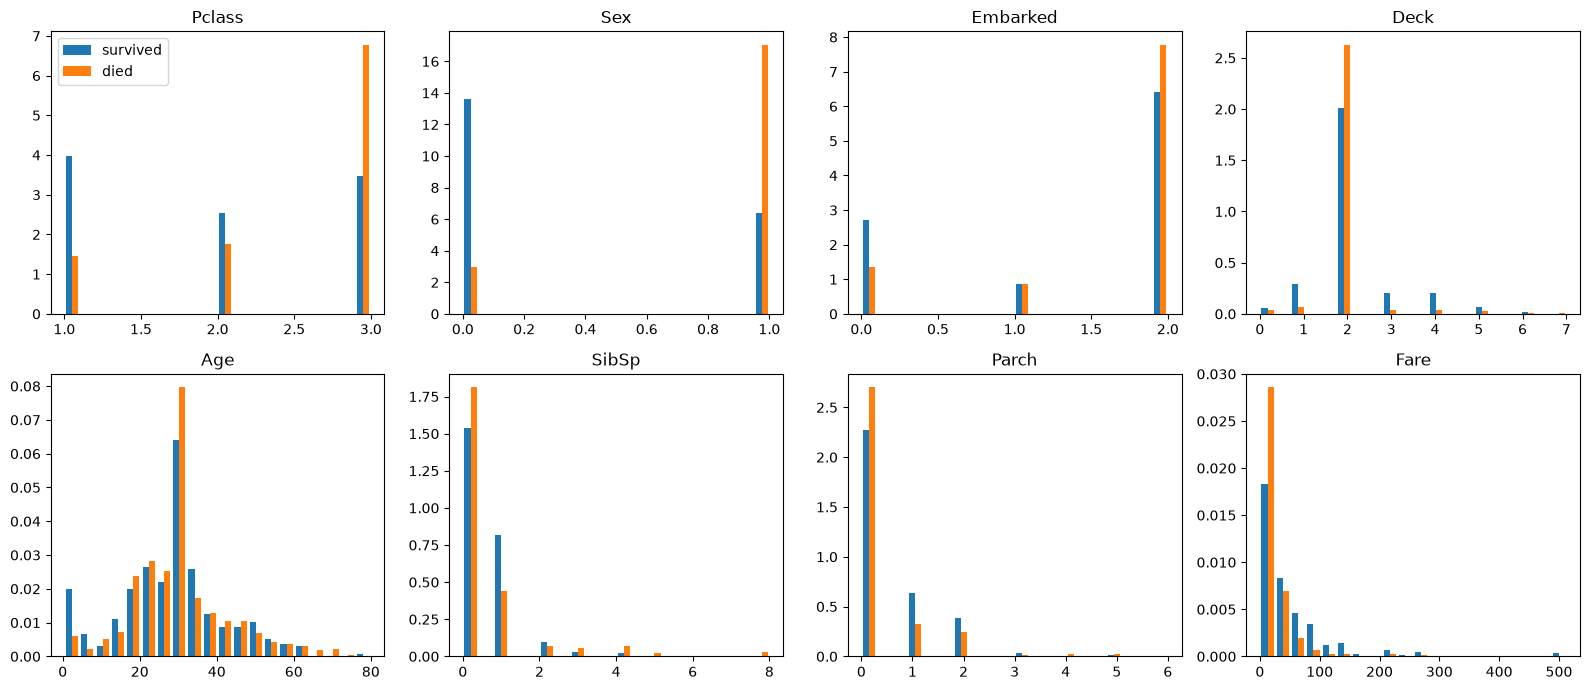

Survivors closest to the average survivor:
     Survived  Pclass  Sex        Age  SibSp  Parch   Fare  Embarked  Deck  \
669         1       1    0  29.699118      1      0  52.00         2     2   
290         1       1    0  26.000000      0      0  78.85         2     2   
383         1       1    0  35.000000      1      0  52.00         2     2   
3           1       1    0  35.000000      1      0  53.10         2     2   
596         1       2    0  29.699118      0      0  33.00         2     2   

     distance  
669  1.046941  
290  1.100917  
383  1.123522  
3    1.134000  
596  1.204337  

Non-survivors closest to the average non-survivor:
     Survived  Pclass  Sex        Age  SibSp  Parch    Fare  Embarked  Deck  \
868         0       3    1  29.699118      0      0  9.5000         2     2   
158         0       3    1  29.699118      0      0  8.6625         2     2   
45          0       3    1  29.699118      0      0  8.0500         2     2   
77          0       3   

In [10]:
import matplotlib.pyplot as plt

# Distribution of each variable in the two groups (density=True so the groups are comparable)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), categorical_features + numerical_features):
    ax.hist([survived[col], died[col]], bins=20, density=True, label=['survived', 'died'])
    ax.set_title(col)
axes[0, 0].legend()
plt.tight_layout()
plt.show()

# Distance from every passenger to the two average passengers. The features are
# scaled to mean 0 and std 1 first so that Fare doesn't dominate the distance.
features = df[categorical_features + numerical_features]
mean = features.mean()
std = features.std()
scaled = (features - mean) / std

def distance_to(avg):
    return np.sqrt(((scaled - (avg - mean) / std) ** 2).sum(axis=1))

dist_survivor = distance_to(avg_survivor)
dist_non_survivor = distance_to(avg_non_survivor)

print('Survivors closest to the average survivor:')
print(survived.assign(distance=dist_survivor).nsmallest(5, 'distance'))
print('\nNon-survivors closest to the average non-survivor:')
print(died.assign(distance=dist_non_survivor).nsmallest(5, 'distance'))
print('\nSurvivors closest to the average non-survivor:')
print(survived.assign(distance=dist_non_survivor).nsmallest(5, 'distance'))
print('\nNon-survivors closest to the average survivor:')
print(died.assign(distance=dist_survivor).nsmallest(5, 'distance'))

The average non-survivor (a man in 3rd class who embarked at Southampton, travelling alone with a cheap ticket) represents his group well. The histograms show that most non-survivors were men in 3rd class, and there are many real non-survivors that are almost identical to the average one (distance below 0.05).

The average survivor (a woman in 1st class from Southampton) is less representative. Survivors were a more mixed group: they come from all three classes and about a third of them are men. Even the closest real survivor is at a distance of about 1, because the median fare of 26 is low for someone in 1st class, so the average survivor is not really a typical passenger.

There are also passengers that look like the other group's average. Several survivors are 3rd class men who are just as close to the average non-survivor as the non-survivors themselves. The other way around, the non-survivors closest to the average survivor are women in 2nd class, but they are still quite far from it.

Both averages have age 29.7 and deck C, which come from the imputation (the spike in the Age histogram and the huge bar for deck 2), so those two features don't really tell the groups apart.

4. Next, let's continue the analysis by looking into pairwise and multivariate relationships between the variables in the two groups. Try to visualize two variables at a time using, e.g., scatter plots and use a different color to encode the survival status.

    <span style="font-weight: 500">*Hint 1: You can also check out Seaborn's pairplot function, if you wish.*</span>

    <span style="font-weight: 500">*Hint 2: To better show many data points with the same value for a given variable, you can use either transparency or ‘jitter’.*</span>

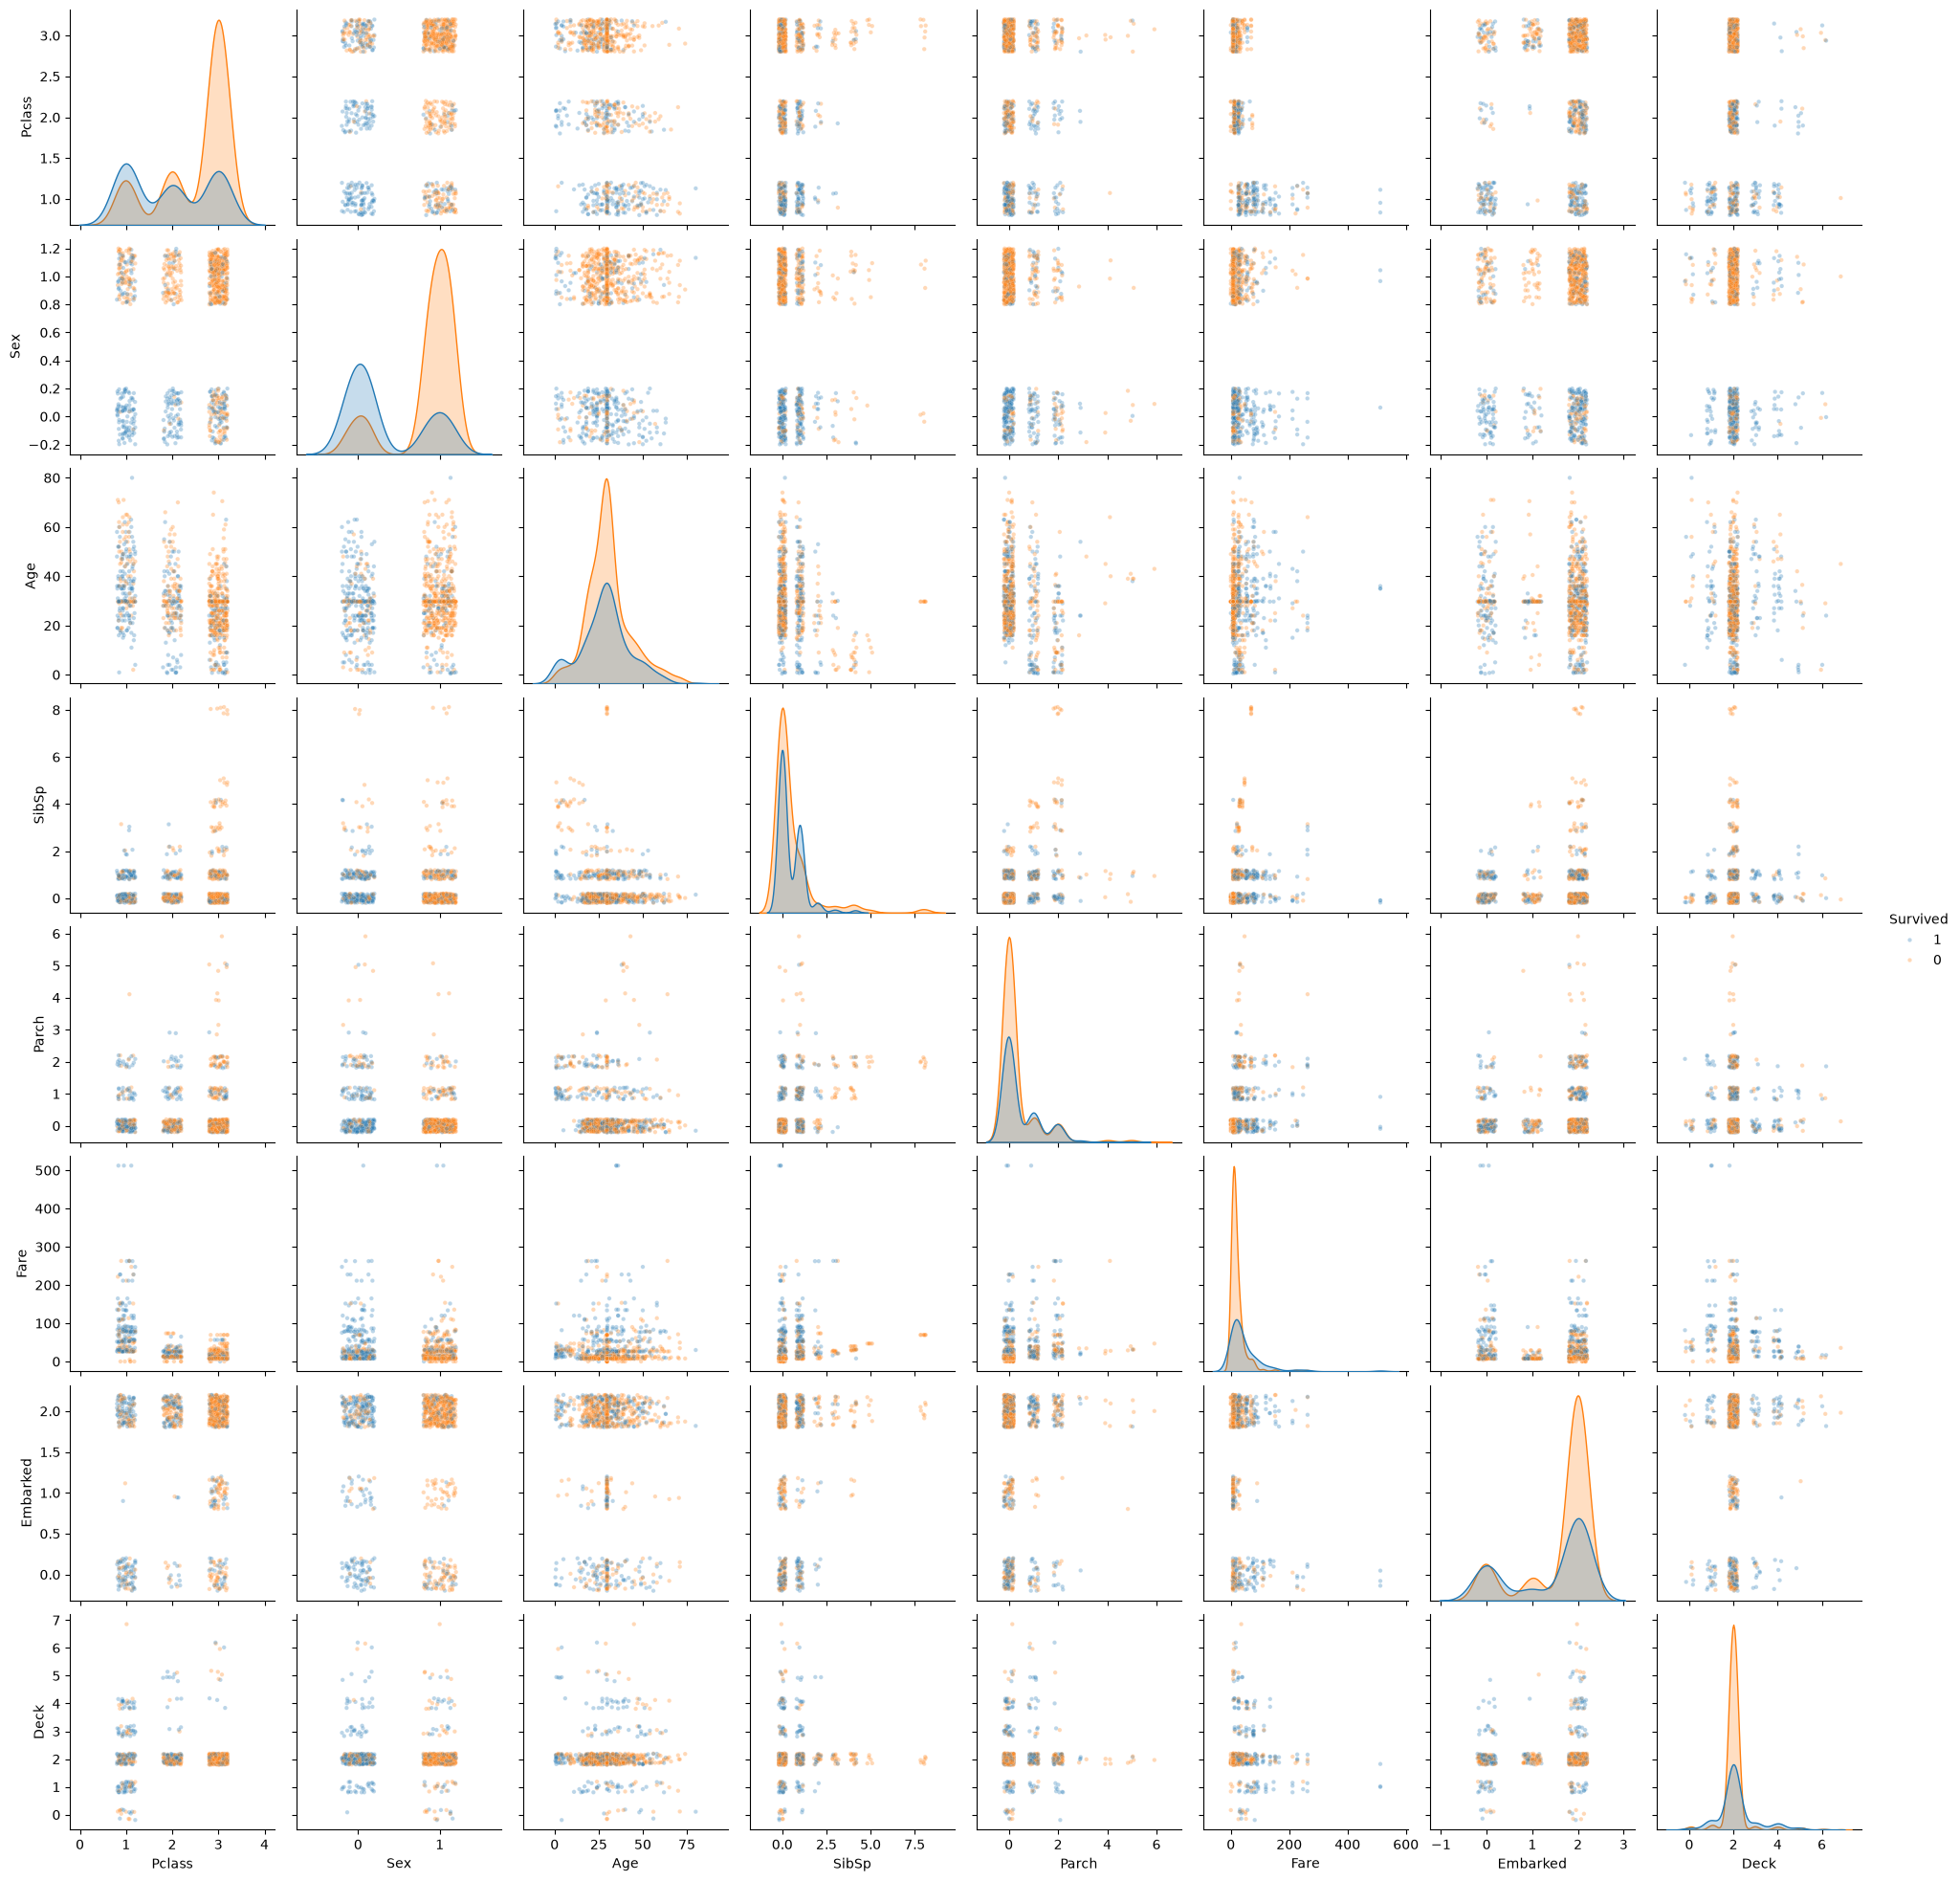

In [11]:
import seaborn as sns

# Add a bit of jitter to the discrete columns so points with the same value don't overlap
jittered = df.copy()
for col in ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked', 'Deck']:
    jittered[col] = jittered[col] + np.random.uniform(-0.2, 0.2, len(df))

sns.pairplot(jittered, hue='Survived', hue_order=[1, 0], plot_kws={'alpha': 0.3, 's': 10})
plt.show()

5. Finally, recall the preprocessing we did in the first exercise. What can you say about the effect of the choices that were made to use the mode and mean to impute missing values, instead of, for example, ignoring passengers with missing data?

If we had ignored passengers with missing data, we would have lost most of the dataset, because Deck is missing for 687 of the 891 passengers. The passengers with a known cabin were mostly in 1st class, so the remaining data would also be biased towards richer passengers who survived more often. Imputing keeps all passengers.

However, imputation also changes the data. The 177 passengers with a missing age all got the mean age 29.7, which creates the big spike in the Age histogram, makes the age distribution narrower, and is the reason both "average" passengers have age 29.7. For Deck, filling in the mode C means that deck C now also contains all the passengers whose cabin was unknown (687 of them, mostly in 3rd class), so it no longer really means deck C and it makes deck C look like a bad deck for survival. It would probably have been better to use a separate "unknown" category for Deck. Embarked had only 2 missing values, so the imputation there makes no real difference.

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 3 | Working with text data 2.0

This exercise is related to the second exercise from last week. Find the saved <span style="font-weight: 500">pos.txt</span> and <span style="font-weight: 500">neg.txt</span> files, or, alternatively, you can find the week 1 example solutions on the MOOC platform after Tuesday.

1. Find the most common words in each file (positive and negative). Examine the results. Do they tend to be general terms relating to the nature of the data? How well do they indicate positive/negative sentiment?

In [12]:
from collections import Counter

with open('pos.txt', encoding='utf-8') as f:
    pos_text = f.read()
with open('neg.txt', encoding='utf-8') as f:
    neg_text = f.read()

pos_counts = Counter(pos_text.split())
neg_counts = Counter(neg_text.split())

print('Positive:', pos_counts.most_common(20))
print('Negative:', neg_counts.most_common(20))

Positive: [('great', 435906), ('work', 427780), ('use', 345233), ('good', 291448), ('fit', 273505), ('instal', 229408), ('product', 210084), ('look', 181401), ('just', 180420), ('like', 175725), ('easi', 162864), ('light', 147321), ('car', 147195), ('price', 144891), ('need', 136519), ('perfect', 124405), ('time', 123938), ('replac', 122261), ('qualiti', 119732), ('nice', 119314)]
Negative: [('work', 39998), ('use', 37244), ('fit', 31293), ('product', 24394), ('just', 23580), ('light', 22907), ('like', 20685), ('time', 19665), ('look', 18824), ('instal', 18709), ('did', 18446), ('good', 17295), ('dont', 17136), ('buy', 16885), ('car', 16694), ('return', 15227), ('tri', 14957), ('doe', 14201), ('replac', 13509), ('didnt', 13045)]


The most common words are mostly general words about the products (car parts and accessories) and how they are used, like work, use, fit, instal, product and light, and 13 of the top 20 words are the same in both files. The positive list does have some clear sentiment words (great is the most common word, and good, easi, perfect and nice are also there), but the negative list has almost none, only return, dont and didnt. Good is even the 12th most common word in the negative reviews, probably from phrases like "not good" where "not" was removed as a stop word. So the most common words say something about the positive reviews but not much about the negative ones.

2. Compute a [TF/IDF](https://en.wikipedia.org/wiki/Tf–idf) vector for each of the two text files, and make them into a <span style="font-weight: 500">2 x m</span> matrix, where <span style="font-weight: 500">m</span> is the number of unique words in the data. The problem with using the most common words in a review to analyze its contents is that words that are common overall will be common in all reviews (both positive and negative). This means that they probably are not good indicators about the sentiment of a specific review. TF/IDF stands for Term Frequency / Inverse Document Frequency (here the reviews are the documents), and is designed to help by taking into consideration not just the number of times a term occurs (term frequency), but also how many times a word exists in other reviews as well (inverse document frequency). You can use any variant of the formula, as well as off-the-shelf implementations. <span style="font-weight: 500">*Hint: You can use [sklearn](http://scikit-learn.org/).*</span>

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Each file is one document
vectorizer = TfidfVectorizer()
tfidf = vectorizer.fit_transform([pos_text, neg_text]).toarray()
words = vectorizer.get_feature_names_out()
print(tfidf.shape)

(2, 235581)


3. List the words with the highest TF/IDF score in each class (positive | negative), and compare them to the most common words. What do you notice? Did TF/IDF work as expected?

In [14]:
for name, row in zip(['Positive', 'Negative'], tfidf):
    top = row.argsort()[::-1][:20]
    print(name, [f'{words[i]} ({row[i]:.3f})' for i in top])

Positive ['great (0.367)', 'work (0.360)', 'use (0.290)', 'good (0.245)', 'fit (0.230)', 'instal (0.193)', 'product (0.177)', 'look (0.153)', 'just (0.152)', 'like (0.148)', 'easi (0.137)', 'light (0.124)', 'car (0.124)', 'price (0.122)', 'need (0.115)', 'perfect (0.105)', 'time (0.104)', 'replac (0.103)', 'qualiti (0.101)', 'nice (0.100)']
Negative ['work (0.302)', 'use (0.281)', 'fit (0.236)', 'product (0.184)', 'just (0.178)', 'light (0.173)', 'like (0.156)', 'time (0.148)', 'look (0.142)', 'instal (0.141)', 'did (0.139)', 'good (0.130)', 'dont (0.129)', 'buy (0.127)', 'car (0.126)', 'return (0.115)', 'tri (0.113)', 'doe (0.107)', 'replac (0.102)', 'didnt (0.098)']


The top TF/IDF words are the same as the most common words, even in the same order, so TF/IDF didn't really work as expected here. The problem is that there are only two documents. The IDF part depends only on how many documents a word appears in, so it can only have two values: every word that appears in both files gets the same (lowest) IDF, and words that appear in only one of the files get a slightly higher one. All the common words appear in both files, so their ranking is decided only by how often they appear. The words that appear in only one file are rare words, so even with the higher IDF they don't get anywhere near the top. TF/IDF would probably work better if every review was its own document instead of the whole file.

4. Plot the words in each class with their corresponding TF/IDF scores. Note that there will be a lot of words, so you’ll have to think carefully to make your chart clear! If you can’t plot them all, plot a subset – think about how you should choose this subset.

    <span style="font-weight: 500">*Hint: you can use word clouds. But feel free to challenge yourselves to think of any other meaningful way to visualize this information!*</span>

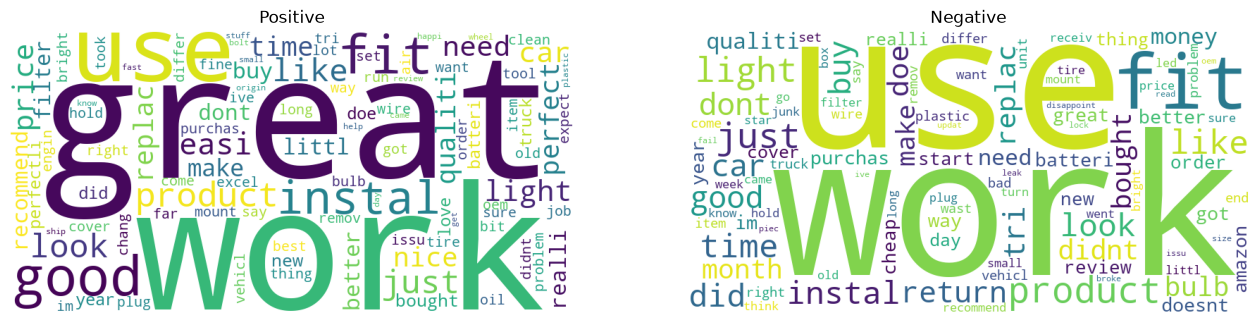

In [15]:
from wordcloud import WordCloud

# There are too many words to plot all of them, so only the 100 words with the
# highest TF/IDF score in each class are shown, sized by their score
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, name, row in zip(axes, ['Positive', 'Negative'], tfidf):
    scores = dict(zip(words, row))
    cloud = WordCloud(background_color='white', max_words=100, width=800, height=400).generate_from_frequencies(scores)
    ax.imshow(cloud)
    ax.set_title(name)
    ax.axis('off')
plt.show()

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 4 | Junk charts

There’s a thriving community of chart enthusiasts who keep looking for statistical graphics that they find inappropriate, and which they call “junk charts”, and who often also propose ways to improve them.

1. Find at least three statistical visualizations you think are not very good and identify their problems. Copying examples from various junk chart websites is not accepted – you should find your own junk charts, out in the wild. You should be able to find good (or rather, bad) examples quite easily since a significant fraction of charts can have at least *some* issues. The examples you choose should also have different problems, e.g., try to avoid collecting three bar charts, all with problematic axes. Instead, try to find as interesting and diverse examples as you can.

2. Try to produce improved versions of the charts you selected. The data is of course often not available, but perhaps you can try to extract it, at least approximately, from the chart. Or perhaps you can simulate data that looks similar enough to make the point.



**Submit a PDF with all the charts (the ones you found and the ones you produced).**

### Chart 1: "The Smartest AI Models in 2026"

Source: Visual Capitalist, 24 April 2026, https://www.visualcapitalist.com/ranked-the-smartest-ai-models-in-2026/ (data: TrackingAI, Mensa Norway test)

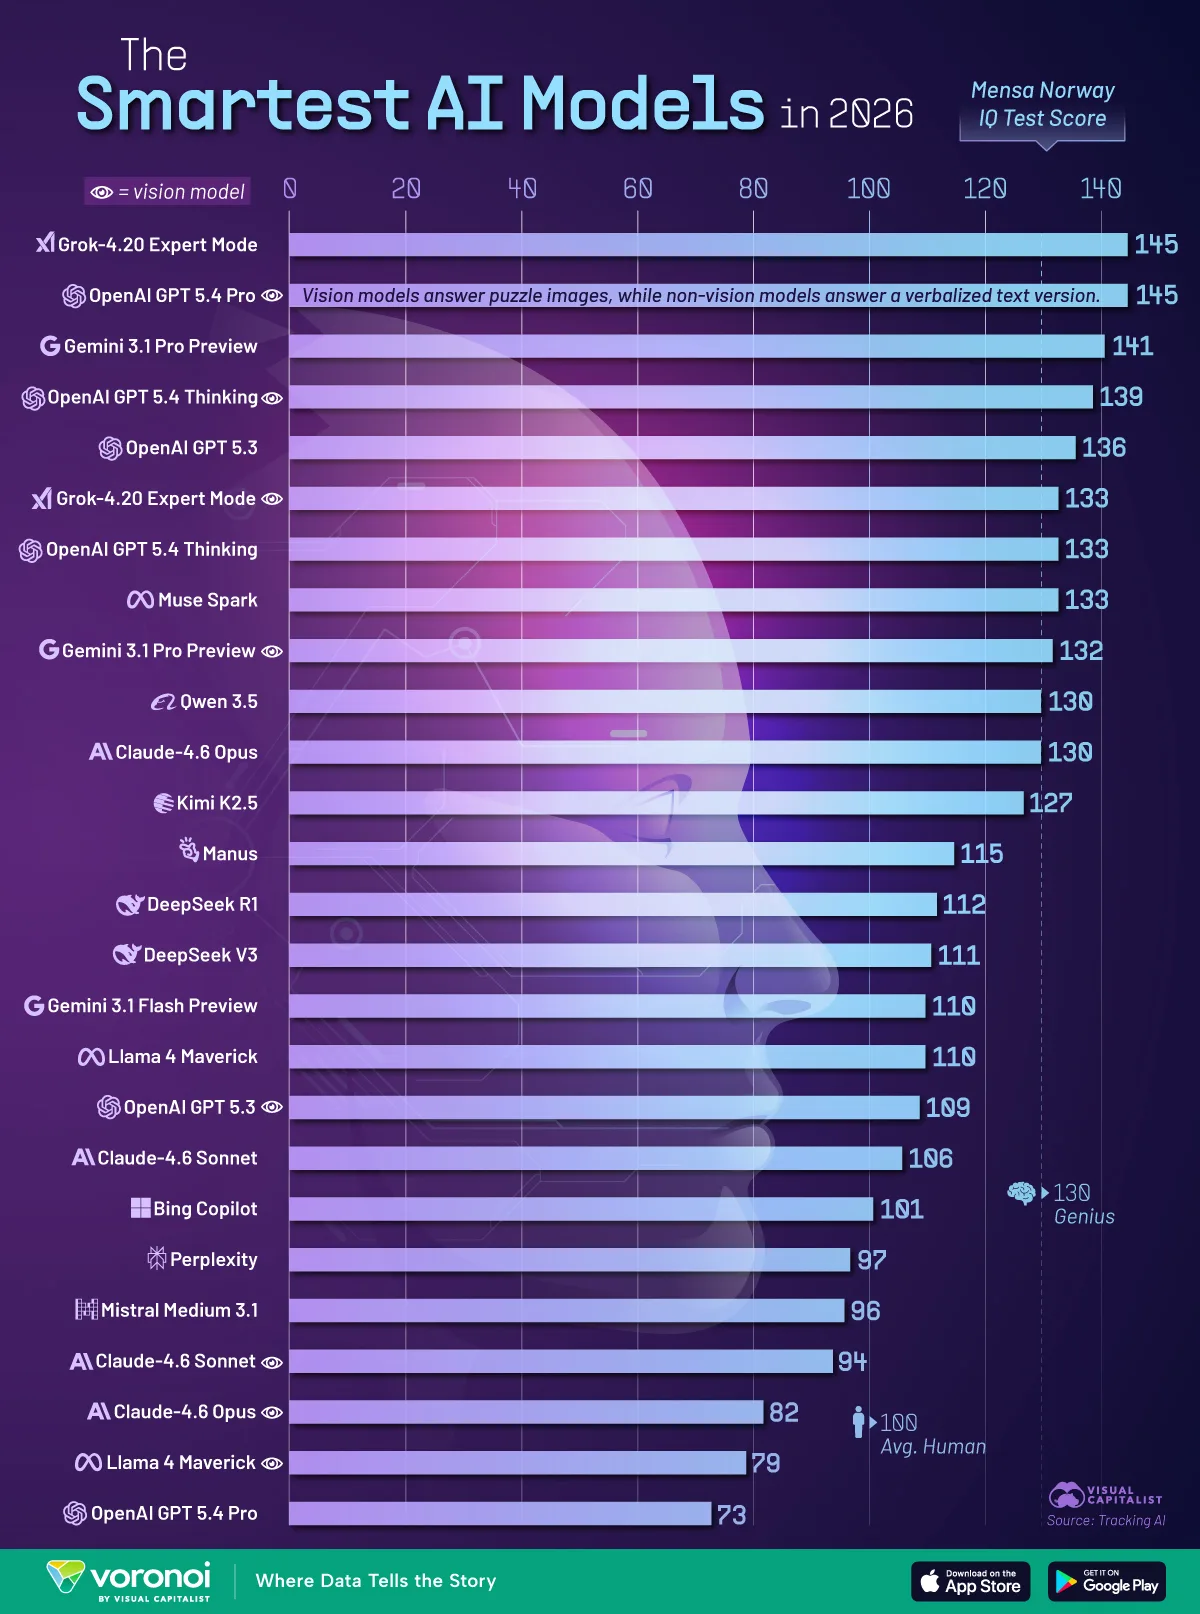

**Problems:**
- The bar lengths are misleading. Representation (length, area) should be directly proportional to the number, which is why bar charts have to start at zero. These bars do start at zero, but an IQ score has no meaningful zero (the scale is fixed so that the average is 100), so a bar twice as long does not mean twice as intelligent. Still, the text version of GPT 5.4 Pro (73) looks half as smart as the top models (145). A bar chart is the wrong choice for this kind of scale.
- Low data-ink ratio: the face illustration, the glowing gradient bars and the background add a lot of ink that shows no data. This is design variation, not data variation.
- The chart depends on a legend. Whether a score comes from the text or the image version of the test is only shown by a small eye icon that is explained in a corner, so GPT 5.4 Pro appears both first (145) and last (73) without it being obvious why. The labelling should be on the graphic itself.
- Compared to what? The most important comparison, the average human at 100, is only a floating label in the bottom corner with no line across the chart.

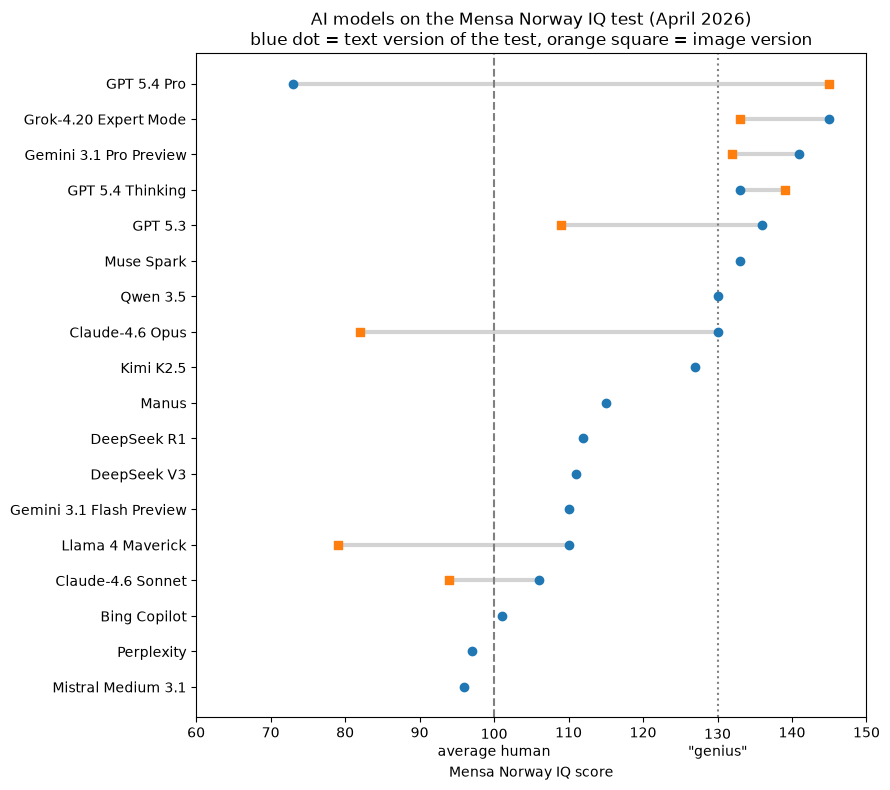

In [16]:
# Scores from the original chart. Most models were tested twice: on a text version
# of the puzzles and on the original images (vision). NaN = no vision score.
iq = pd.DataFrame({
    'model': ['Grok-4.20 Expert Mode', 'GPT 5.4 Pro', 'Gemini 3.1 Pro Preview', 'GPT 5.4 Thinking',
              'GPT 5.3', 'Muse Spark', 'Qwen 3.5', 'Claude-4.6 Opus', 'Kimi K2.5', 'Manus',
              'DeepSeek R1', 'DeepSeek V3', 'Gemini 3.1 Flash Preview', 'Llama 4 Maverick',
              'Claude-4.6 Sonnet', 'Bing Copilot', 'Perplexity', 'Mistral Medium 3.1'],
    'text':   [145, 73, 141, 133, 136, 133, 130, 130, 127, 115, 112, 111, 110, 110, 106, 101, 97, 96],
    'vision': [133, 145, 132, 139, 109, np.nan, np.nan, 82, np.nan, np.nan, np.nan, np.nan, np.nan, 79, 94,
               np.nan, np.nan, np.nan],
})
iq['best'] = iq[['text', 'vision']].max(axis=1)
iq = iq.sort_values('best')

fig, ax = plt.subplots(figsize=(9, 8))
ax.hlines(iq['model'], iq['text'], iq['vision'], color='lightgrey', linewidth=3)  # joins the two scores
ax.scatter(iq['text'], iq['model'], color='tab:blue', zorder=3)
ax.scatter(iq['vision'], iq['model'], color='tab:orange', marker='s', zorder=3)
ax.axvline(100, color='grey', linestyle='--')
ax.axvline(130, color='grey', linestyle=':')

ax.set_xticks([60, 70, 80, 90, 100, 110, 120, 130, 140, 150])
ax.set_xticklabels(['60', '70', '80', '90', '100\naverage human', '110', '120', '130\n"genius"', '140', '150'])
ax.set_xlabel('Mensa Norway IQ score')
ax.set_title('AI models on the Mensa Norway IQ test (April 2026)\n'
             'blue dot = text version of the test, orange square = image version')
plt.tight_layout()
plt.show()

**Improvement:** Each model is one row, with its two scores as dots joined by a line. Dots show the value by position instead of length, so the axis can start at 60 without distorting anything, like the graduation rate line chart in the lecture that starts at 70. The decoration is removed, the title explains the two markers instead of a separate legend, and the average human and "genius" levels are lines across the whole chart, labelled on the axis. This also shows something the original hides: for several models the gap between the text and image versions of the test is bigger than the differences between most of the models.

### Chart 2: Alphabet (GOOGL) GF Value chart

Source: GuruFocus via TradingView News, 9 September 2026, https://www.tradingview.com/news/gurufocus:e87f0e463094b:0-alphabet-drops-3-after-google-commits-13-billion-to-finland-ai/

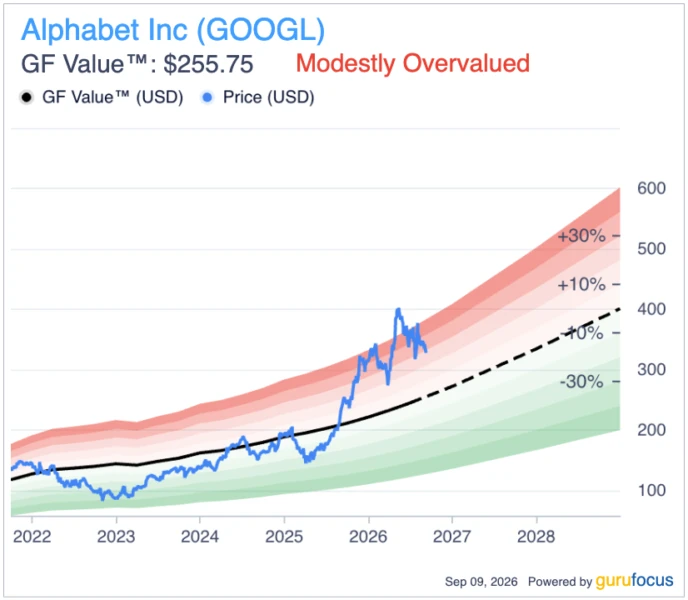

**Problems:**
- Above all else, show the data. About a third of the chart (Sep 2026 to 2028) is not data but GuruFocus's projection of its own GF Value, drawn just as prominently as the real history. Only a dashed line hints at this and the legend does not mention it, a bit like the NASA example where the important information was in the fine print.
- Red and green: the bands use red for "overvalued" and green for "undervalued". Red and green are hard to tell apart for colour-blind readers, and they carry a good vs bad connotation, which here quietly turns the chart into a buy/sell judgement.
- Unclear labelling and a lot of non-data ink: six shades of coloured bands fill most of the chart, their labels (+30%, +10%, -10%, -30%) float between the bands so it is unclear what they refer to, "-10%" sits on top of the dashed line, and the y-axis has no unit.

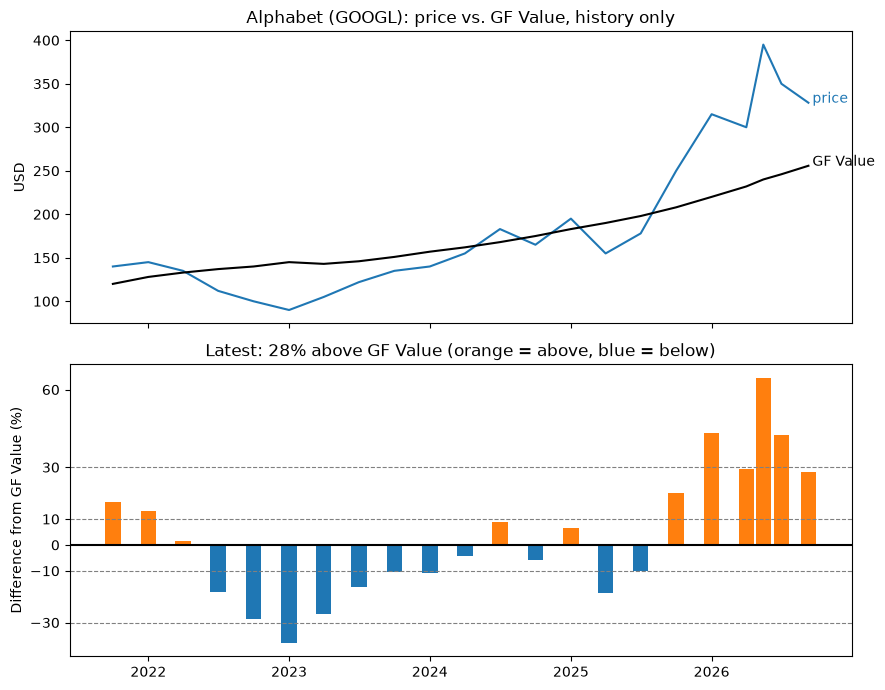

In [17]:
# Values read off the original chart by eye (approximate), except the last point,
# which is from the article: price $328.20 and GF Value $255.75 on 9 Sep 2026
googl = pd.DataFrame({
    'date': ['2021-10-01', '2022-01-01', '2022-04-01', '2022-07-01', '2022-10-01', '2023-01-01',
             '2023-04-01', '2023-07-01', '2023-10-01', '2024-01-01', '2024-04-01', '2024-07-01',
             '2024-10-01', '2025-01-01', '2025-04-01', '2025-07-01', '2025-10-01', '2026-01-01',
             '2026-04-01', '2026-05-15', '2026-07-01', '2026-09-09'],
    'price':    [140, 145, 135, 112, 100, 90, 105, 122, 135, 140, 155, 183,
                 165, 195, 155, 178, 250, 315, 300, 395, 350, 328.20],
    'gf_value': [120, 128, 133, 137, 140, 145, 143, 146, 151, 157, 162, 168,
                 175, 183, 190, 198, 208, 220, 232, 240, 246, 255.75],
})
googl['date'] = pd.to_datetime(googl['date'])
googl['diff'] = (googl['price'] / googl['gf_value'] - 1) * 100  # % above (+) or below (-) GF Value

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

# Top: price and GF Value, with the names written at the end of each line
ax1.plot(googl['date'], googl['price'], color='tab:blue')
ax1.plot(googl['date'], googl['gf_value'], color='black')
ax1.text(googl['date'].iloc[-1], googl['price'].iloc[-1], ' price', color='tab:blue')
ax1.text(googl['date'].iloc[-1], googl['gf_value'].iloc[-1], ' GF Value')
ax1.margins(x=0.12)  # extra space on the right for the line labels
ax1.set_ylabel('USD')
ax1.set_title('Alphabet (GOOGL): price vs. GF Value, history only')

# Bottom: the difference as bars (orange = above GF Value, blue = below)
colors = ['tab:orange' if d > 0 else 'tab:blue' for d in googl['diff']]
ax2.bar(googl['date'], googl['diff'], width=40, color=colors)
ax2.axhline(0, color='black')
for level in [-30, -10, 10, 30]:
    ax2.axhline(level, color='grey', linestyle='--', linewidth=0.8)
ax2.set_yticks([-30, -10, 0, 10, 30, 60])
ax2.set_ylabel('Difference from GF Value (%)')
ax2.set_title('Latest: 28% above GF Value (orange = above, blue = below)')

plt.tight_layout()
plt.show()

**Improvement:** The projection is removed, so everything shown is real data, and the y-axis has a unit. The bottom panel shows directly what the "overvalued" verdict is about: how many percent the price is above or below GF Value, as bars that start at zero, with the ±10% and ±30% levels as simple lines. Orange and blue replace red and green, and the two lines in the top panel are labelled at their ends instead of in a legend.

### Chart 3: Athletic Apparel Companies, Indexed New Customers

Source: Bloomberg Second Measure, 1 October 2020, https://secondmeasure.com/datapoints/gymsharks-new-customer-acquisition-is-devouring-the-competition/

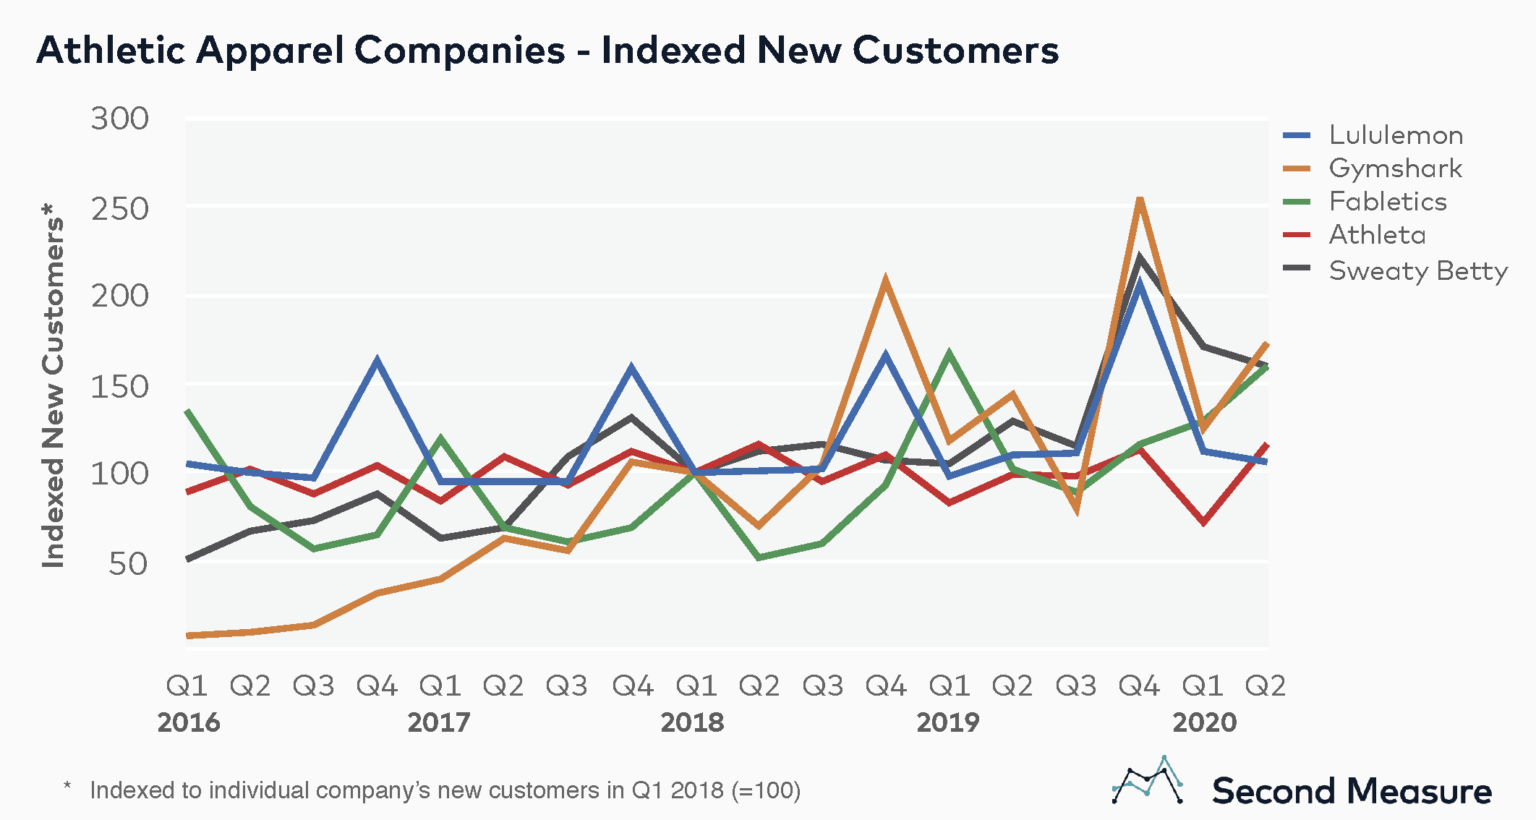

**Problems:**
- Compared to what? Every company is indexed to its own Q1 2018 (= 100), so the chart only compares each company with itself and hides how big the companies are. According to the same article, Gymshark had only 3% of the five brands' 2019 sales, compared with 56% for Lululemon, but on the chart Gymshark looks just as important. This is the kind of switch between the raw figure and the conclusion that Huff warns about: from indexed growth numbers to a headline saying Gymshark is "devouring the competition".
- Five overlapping lines can only be told apart through the legend, and the legend order does not even match the order of the lines. The labelling should be on the graphic itself.
- The Q4 holiday spikes are the most visible thing in the chart and hide the underlying trends. The Akava unemployment chart in the lecture handles this by drawing a smoothed trend line on top of the raw values.

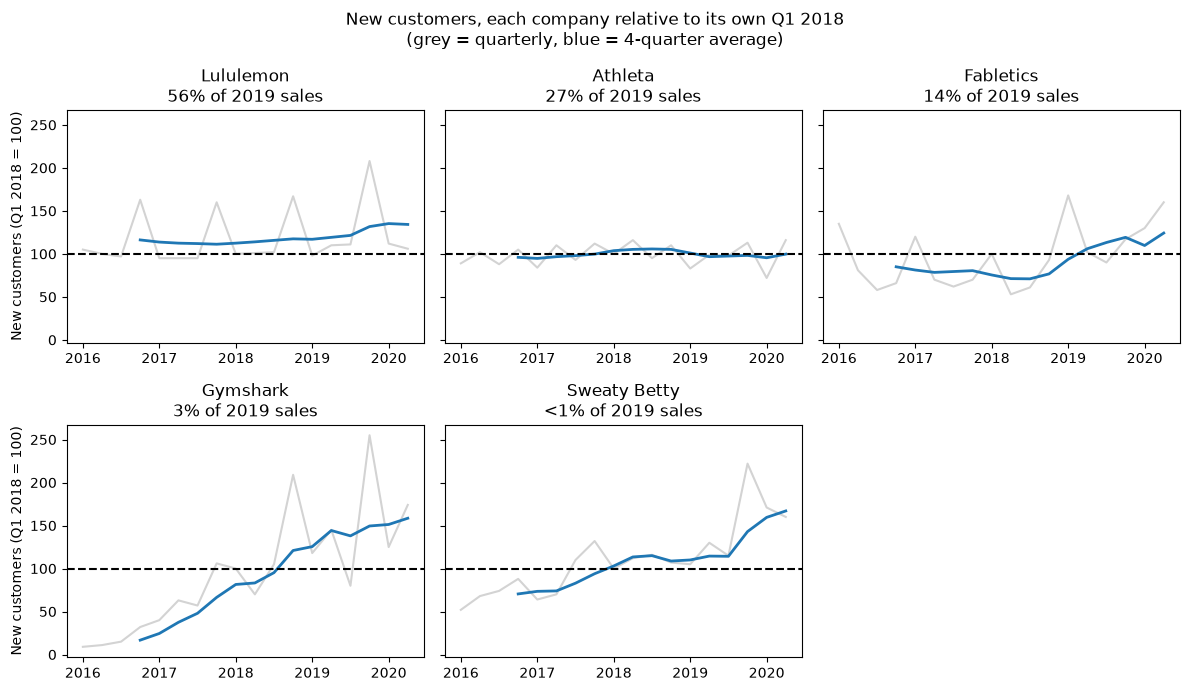

In [18]:
# New customers indexed to each company's own Q1 2018 (= 100), read off the
# original chart by eye (approximate). One value per quarter, Q1 2016 to Q2 2020.
customers = pd.DataFrame({
    'Lululemon':    [105, 100, 97, 163, 95, 95, 95, 160, 100, 101, 102, 167, 98, 110, 111, 208, 112, 106],
    'Athleta':      [89, 102, 88, 105, 84, 110, 93, 112, 100, 116, 95, 110, 83, 99, 98, 113, 72, 116],
    'Fabletics':    [135, 81, 58, 66, 120, 70, 62, 70, 100, 53, 61, 93, 168, 102, 90, 117, 130, 160],
    'Gymshark':     [9, 11, 15, 32, 40, 63, 57, 106, 100, 70, 105, 209, 118, 145, 80, 255, 125, 174],
    'Sweaty Betty': [52, 68, 74, 88, 64, 70, 110, 132, 100, 112, 116, 107, 105, 130, 115, 222, 171, 160],
})
customers.index = np.arange(2016, 2020.5, 0.25)  # quarters as years: 2016.0, 2016.25, ...

# Share of the five brands' combined 2019 US sales, from the same article
shares = ['56%', '27%', '14%', '3%', '<1%']

# One small plot per company, all with the same y-axis (2 rows x 3 columns, last spot left empty)
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey=True)
axes = axes.flatten()
axes[5].axis('off')
for i, company in enumerate(customers.columns):
    axes[i].plot(customers[company], color='lightgrey')
    axes[i].plot(customers[company].rolling(4).mean(), color='tab:blue', linewidth=2)  # average of last 4 quarters
    axes[i].axhline(100, color='black', linestyle='--')
    axes[i].set_title(company + '\n' + shares[i] + ' of 2019 sales')

axes[0].set_ylabel('New customers (Q1 2018 = 100)')
axes[3].set_ylabel('New customers (Q1 2018 = 100)')
fig.suptitle('New customers, each company relative to its own Q1 2018\n(grey = quarterly, blue = 4-quarter average)')
plt.tight_layout()
plt.show()

**Improvement:** Small multiples: each company gets its own panel on the same y-axis, so nothing overlaps and each panel is labelled directly with the company name. Like in the Akava example, a 4-quarter average shows the trend, with the quarterly values kept in light grey. The absolute customer numbers are not published, so the index can't be undone, but each panel title now answers "compared to what?" with the brand's share of 2019 sales, which shows that Gymshark's fast growth starts from a very small base.